<a href="https://colab.research.google.com/github/Basmala135/grad_project/blob/main/Grad_version3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [2]:
!ls -lah "/content/drive/MyDrive"


ls: '/content/drive/MyDrive/normal data': No such file or directory
ls: '/content/drive/MyDrive/fall data': No such file or directory
total 603M
-rw------- 1 root root  1.1M Mar  5  2025  21010359_perihanetarek.pdf
-rw------- 1 root root  1.8M Apr 14  2025  21010428_21010366_21010359_21010994_AnalogIc_Lab1.pdf
-rw------- 1 root root  8.0K Dec 14  2024  30206100202621.jpg
-rw------- 1 root root   21K Dec 14  2024  30206100202621.pdf
-rw------- 1 root root  1.8M May  8  2025 'ANALOG IC 3.pdf'
-rw------- 1 root root  2.0M Dec 20 20:34  antenna_lab2.pdf
-rw------- 1 root root  2.7M Dec 19 20:08  Antenna_reports.pdf
-rw------- 1 root root  6.6M Aug  5  2025  Assign2_21010359.pdf
-rw------- 1 root root   16M Aug 15  2025  Assign4.pdf
-rw------- 1 root root  6.9M Aug 23  2025  Assign5_21010359.pdf
-rw------- 1 root root  8.2M Aug 25  2025  Assign6_21010359.pdf
-rw------- 1 root root   18M Aug 27  2025  Assign7-21010359.pdf
-rw------- 1 root root   17M Sep  1  2025  Assign8-21010359.pdf
-rw---

In [3]:
import pandas as pd

NORMAL_CSV = "/content/drive/MyDrive/Normal_labeked/Copy of all_labeled_training_data.csv"

df = pd.read_csv(NORMAL_CSV)
print(f"Loaded normal labeled dataset: {NORMAL_CSV}")


Loaded normal labeled dataset: /content/drive/MyDrive/Normal_labeked/Copy of all_labeled_training_data.csv


In [4]:
print("=== SHAPE ===")
print(df.shape)

print("\n=== COLUMNS ===")
print(df.columns.tolist())

print("\n=== FIRST 3 ROWS ===")
print(df.head(3))

print("\n=== LABEL COUNTS ===")
print(df["label"].value_counts())

print("\n=== RIDER COUNTS ===")
if "Rider" in df.columns:
    print(df["Rider"].value_counts())
else:
    print("No Rider column found.")

print("\n=== SENSOR RANGES ===")
normal_channels = ["Acc_X", "Acc_Y", "Acc_Z", "Gyr_X", "Gyr_Y", "Gyr_Z"]
print(df[normal_channels].describe().loc[["min", "mean", "max", "std"]])

print("\n=== NULL VALUES ===")
print(df.isnull().sum())

print("\n=== DTYPES ===")
print(df.dtypes)


=== SHAPE ===
(5102330, 24)

=== COLUMNS ===
['Unnamed: 0', 'PacketCounter', 'SampleTimeFine', 'Acc_X', 'Acc_Y', 'Acc_Z', 'Gyr_X', 'Gyr_Y', 'Gyr_Z', 'Mag_X', 'Mag_Y', 'Mag_Z', 'VelInc_X', 'VelInc_Y', 'VelInc_Z', 'OriInc_q0', 'OriInc_q1', 'OriInc_q2', 'OriInc_q3', 'Roll', 'Pitch', 'Yaw', 'Rider', 'label']

=== FIRST 3 ROWS ===
   Unnamed: 0  PacketCounter  SampleTimeFine     Acc_X     Acc_Y      Acc_Z  \
0       83245          47920        22720080  3.632364  4.748579  10.098453   
1       83246          47921        22720280 -1.212778  3.044884  13.535365   
2       83247          47922        22720480  4.208983  0.119142   6.793044   

      Gyr_X     Gyr_Y     Gyr_Z     Mag_X  ...  VelInc_Z  OriInc_q0  \
0  1.250994 -0.138326 -0.061255  0.257162  ...  0.204481   0.999921   
1 -0.666899  0.650407 -0.390476  0.242207  ...  0.270159   0.999949   
2 -1.847173 -0.902243 -0.128224  0.271556  ...  0.137181   0.999788   

   OriInc_q1  OriInc_q2  OriInc_q3       Roll     Pitch         Yaw   

In [5]:
import os
import pandas as pd

FALL_FOLDER = "/content/drive/MyDrive/fall data"

csv_files = [
    os.path.join(FALL_FOLDER, file)
    for file in os.listdir(FALL_FOLDER)
    if file.endswith(".csv")
]

print("Number of CSV files:", len(csv_files))

for file_path in csv_files:
    print("\n" + "=" * 80)
    print("FILE:", os.path.basename(file_path))
    print("=" * 80)

    try:
        df_fall_preview = pd.read_csv(
            file_path,
            encoding="latin1",
            sep="\t",
            header=0,
            usecols=[0, 1, 2, 3, 4, 5, 6],
            engine="python",
        )
        df_fall_preview.columns = ["time", "ax", "ay", "az", "gx", "gy", "gz"]
        df_fall_preview = df_fall_preview[["ax", "ay", "az", "gx", "gy", "gz"]]
        df_fall_preview = df_fall_preview.apply(pd.to_numeric, errors="coerce").dropna()
    except Exception as e:
        print("ERROR:", e)
        continue

    print("=== SHAPE ===")
    print(df_fall_preview.shape)

    print("\n=== FIRST 3 ROWS ===")
    print(df_fall_preview.head(3))

    print("\n=== SENSOR RANGES ===")
    print(df_fall_preview.describe().loc[["min", "mean", "max", "std"]])

    print("\n=== DTYPES ===")
    print(df_fall_preview.dtypes)


Number of CSV files: 11

FILE: Harsh breaking On Straight Line.csv
=== SHAPE ===
(111485, 6)

=== FIRST 3 ROWS ===
    ax   ay   az   gx   gy   gz
0  0.0  0.0  0.0  0.0  0.0  0.0
1  0.0  0.0  0.0  0.0  0.0  0.0
2  0.0  0.0  0.0  0.0  0.0  0.0

=== SENSOR RANGES ===
             ax        ay         az         gx         gy         gz
min  -10.161000 -0.145000   0.000000 -45.568000 -28.150000 -54.791000
mean  -0.031125  0.067427   9.742392  -0.376806   0.385915   1.900249
max    9.219000  0.382000  13.783000  95.536000  26.302000  59.664000
std    1.541427  0.056100   0.402716   5.110271   3.823965   8.604053

=== DTYPES ===
ax    float64
ay    float64
az    float64
gx    float64
gy    float64
gz    float64
dtype: object

FILE: Much degraded track.csv
=== SHAPE ===
(132094, 6)

=== FIRST 3 ROWS ===
    ax   ay   az   gx   gy   gz
0  0.0  0.0  0.0  0.0  0.0  0.0
1  0.0  0.0  0.0  0.0  0.0  0.0
2  0.0  0.0  0.0  0.0  0.0  0.0

=== SENSOR RANGES ===
             ax        ay         az    

In [6]:
import pandas as pd

# Just peek at ONE file raw
file_path = "/content/drive/MyDrive/fall data/Fall in a curve.csv"

# Read raw lines to see exactly what's in there
with open(file_path, encoding='latin1') as f:
    for i, line in enumerate(f):
        print(repr(line))  # repr() shows \t and \n characters explicitly
        if i == 4:         # just first 5 lines
            break

'time(s)\tAx(m/s²)\tAy(m/s²)\tAz(m/s²)\tRx(°/s)\tRy.(°/s)\tRz(°/s)\t\t\t\t\t\t\t\t\t\t\n'
'0.001\t0.000\t0.000\t0.000\t0.000\t0.000\t0.000\t\n'
'0.002\t0.000\t0.000\t0.000\t0.000\t0.000\t0.000\t\n'
'0.003\t0.000\t0.000\t0.000\t0.000\t0.000\t0.000\t\n'
'0.004\t0.000\t0.000\t0.000\t0.000\t0.000\t0.000\t\n'


In [7]:
import os
import pandas as pd

folder_path = "/content/drive/MyDrive/fall data"

csv_files = [
    os.path.join(folder_path, file)
    for file in os.listdir(folder_path)
    if file.endswith(".csv")
]

print("Number of CSV files:", len(csv_files))

for file_path in csv_files:
    print("\n" + "="*80)
    print("FILE:", os.path.basename(file_path))
    print("="*80)

    try:
        df = pd.read_csv(
            file_path,
            encoding='latin1',
            sep='\t',
            header=0,
            usecols=[0, 1, 2, 3, 4, 5, 6],   # take exactly the 7 real columns
            engine='python'                    # more flexible with messy files
        )

        # Rename to standard names
        df.columns = ['time', 'ax', 'ay', 'az', 'gx', 'gy', 'gz']

        # Drop time, convert to numeric, drop bad rows
        df = df[['ax', 'ay', 'az', 'gx', 'gy', 'gz']]
        df = df.apply(pd.to_numeric, errors='coerce').dropna()

        print("=== SHAPE ===")
        print(df.shape)

        print("\n=== FIRST 3 ROWS ===")
        print(df.head(3))

        print("\n=== BASIC STATS ===")
        print(df.describe())

        print("\n=== DTYPES ===")
        print(df.dtypes)

    except Exception as e:
        print("ERROR:", e)

Number of CSV files: 11

FILE: Harsh breaking On Straight Line.csv
=== SHAPE ===
(111485, 6)

=== FIRST 3 ROWS ===
    ax   ay   az   gx   gy   gz
0  0.0  0.0  0.0  0.0  0.0  0.0
1  0.0  0.0  0.0  0.0  0.0  0.0
2  0.0  0.0  0.0  0.0  0.0  0.0

=== BASIC STATS ===
                  ax             ay             az             gx  \
count  111485.000000  111485.000000  111485.000000  111485.000000   
mean       -0.031125       0.067427       9.742392      -0.376806   
std         1.541427       0.056100       0.402716       5.110271   
min       -10.161000      -0.145000       0.000000     -45.568000   
25%        -0.097000       0.022000       9.626000      -0.280000   
50%        -0.048000       0.046000       9.680000      -0.110000   
75%        -0.010000       0.094000       9.770000       0.000000   
max         9.219000       0.382000      13.783000      95.536000   

                  gy             gz  
count  111485.000000  111485.000000  
mean        0.385915       1.900249  


In [8]:
import pandas as pd

NORMAL_CSV = "/content/drive/MyDrive/Normal_labeked/Copy of all_labeled_training_data.csv"

df_normal = pd.read_csv(NORMAL_CSV)

print("NORMAL DATA - raw columns:")
print(df_normal.columns.tolist())

normal_channels = ["Acc_X", "Acc_Y", "Acc_Z", "Gyr_X", "Gyr_Y", "Gyr_Z"]
print("\nNORMAL DATA - sensor ranges:")
print(df_normal[normal_channels].describe().loc[["min", "mean", "max", "std"]])

print("\nLabel counts:")
print(df_normal["label"].value_counts())


NORMAL DATA - raw columns:
['Unnamed: 0', 'PacketCounter', 'SampleTimeFine', 'Acc_X', 'Acc_Y', 'Acc_Z', 'Gyr_X', 'Gyr_Y', 'Gyr_Z', 'Mag_X', 'Mag_Y', 'Mag_Z', 'VelInc_X', 'VelInc_Y', 'VelInc_Z', 'OriInc_q0', 'OriInc_q1', 'OriInc_q2', 'OriInc_q3', 'Roll', 'Pitch', 'Yaw', 'Rider', 'label']

NORMAL DATA - sensor ranges:
          Acc_X      Acc_Y      Acc_Z      Gyr_X     Gyr_Y     Gyr_Z
min  -74.982368 -19.149508 -32.528603 -10.429083 -9.959892 -9.946112
mean   0.108313   0.116299   9.802591  -0.001509 -0.021097 -0.004627
max   44.319599  77.676262  56.530018  10.239907  9.189062  9.900241
std    2.469618   1.166282   1.643060   0.292810  0.216462  0.144531

Label counts:
label
cruise      1949792
traffic     1776147
fun         1075549
wait         279026
overtake      21816
Name: count, dtype: int64


In [9]:
import pandas as pd

NORMAL_CSV = "/content/drive/MyDrive/Normal_labeked/Copy of all_labeled_training_data.csv"

df_normal = pd.read_csv(NORMAL_CSV)

# Keep only riding labels that should represent normal deployment behavior.
KEEP_NORMAL_LABELS = {"cruise", "fun", "overtake"}
df_normal_filtered = df_normal[df_normal["label"].isin(KEEP_NORMAL_LABELS)].copy()

print("Rows before filtering:", f"{len(df_normal):,}")
print("Rows after filtering :", f"{len(df_normal_filtered):,}")
print("Removed labels       :", sorted(set(df_normal["label"]) - KEEP_NORMAL_LABELS))

normal_channels = ["Acc_X", "Acc_Y", "Acc_Z", "Gyr_X", "Gyr_Y", "Gyr_Z"]
print("\nFiltered normal ranges:")
print(df_normal_filtered[normal_channels].describe().loc[["min", "mean", "max", "std"]])

az_mean = df_normal_filtered["Acc_Z"].mean()
gyro_abs_max = df_normal_filtered[["Gyr_X", "Gyr_Y", "Gyr_Z"]].abs().max().max()
print("\nUnit check:")
print(f"  Acc_Z mean = {az_mean:.3f}")
if 7.0 <= az_mean <= 12.0:
    print("  Acceleration already looks like m/s^2. Do NOT multiply by 9.81.")
elif 0.7 <= az_mean <= 1.3:
    print("  Acceleration looks like g. Multiply Acc_X/Acc_Y/Acc_Z by 9.81 before training.")
else:
    print("  Acceleration scale is unusual. Inspect units before training.")

print(f"  Gyro absolute max before scaling = {gyro_abs_max:.3f}")
print("  Fall files use degrees/second and reach about +/-100, so this notebook multiplies normal Gyr_* by 10.")


Rows before filtering: 5,102,330
Rows after filtering : 3,047,157
Removed labels       : ['traffic', 'wait']

Filtered normal ranges:
          Acc_X      Acc_Y      Acc_Z      Gyr_X     Gyr_Y     Gyr_Z
min  -74.982368 -18.030125 -32.528603 -10.289714 -9.959892 -9.946112
mean   0.224653   0.018139   9.821919  -0.001842 -0.027686 -0.004493
max   33.727627  77.676262  56.530018  10.239907  8.982059  9.900241
std    2.621968   1.220575   1.745364   0.311051  0.226682  0.157947

Unit check:
  Acc_Z mean = 9.822
  Acceleration already looks like m/s^2. Do NOT multiply by 9.81.
  Gyro absolute max before scaling = 10.290
  Fall files use degrees/second and reach about +/-100, so this notebook multiplies normal Gyr_* by 10.


In [10]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from sklearn.model_selection import KFold
from sklearn.utils import resample
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_auc_score, precision_recall_curve, auc
)
import tensorflow as tf
from tensorflow import keras

# Paths
# Use the raw normal file. The loader below handles the Acc_X/Gyr_X column names.
NORMAL_CSV = "/content/drive/MyDrive/Normal_labeked/Copy of all_labeled_training_data.csv"
FALL_FOLDER = "/content/drive/MyDrive/fall data"
PROCESSED_DIR = Path("data/processed")
MODELS_DIR = Path("models")
PROCESSED_DIR.mkdir(parents=True, exist_ok=True)
MODELS_DIR.mkdir(exist_ok=True)

# Sensor channels used by the model
CHANNELS = ["ax", "ay", "az", "gx", "gy", "gz"]
NORMAL_COLUMN_MAP = {
    "Acc_X": "ax", "Acc_Y": "ay", "Acc_Z": "az",
    "Gyr_X": "gx", "Gyr_Y": "gy", "Gyr_Z": "gz",
}
NORMAL_GYRO_SCALE = 10.0

# Keep only normal riding modes that are useful for deployment.
KEEP_NORMAL_LABELS = {"cruise", "fun", "overtake"}
DROP_NORMAL_LABELS = {"traffic", "wait"}

# Sliding window config
SAMPLE_RATE = 100
WINDOW_SEC = 2.0
OVERLAP = 0.5
WINDOW_SIZE = int(SAMPLE_RATE * WINDOW_SEC)
STEP_SIZE = int(WINDOW_SIZE * (1 - OVERLAP))

# These files are aggressive-but-normal riding events, not accidents.
# They become hard negatives so the model learns: harsh braking/rough track != fall.
MOVE_TO_NORMAL = {
    "Harsh breaking On Straight Line.csv",
    "Acceleration On Straight Line.csv",
    "Acceleration On Curve.csv",
    "Much degraded track.csv",
}

ACTUAL_FALL_FILES = {
    "Fall Like manoeuvre 1.csv",
    "Fall Like manoeuvre 2.csv",
    "Fall Like manoeuvre 3.csv",
    "Fall with leaning of the motorcycle.csv",
    "Fall in the roundabout.csv",
    "Fall on a slippery straight road section.csv",
    "Fall in a curve.csv",
}

# Training hyperparameters
# Keep these modest in Colab. Early stopping will usually finish before 40.
EPOCHS = 40
BATCH_SIZE = 64
LR = 1e-3
RANDOM_STATE = 42
K = 5

np.random.seed(RANDOM_STATE)
tf.random.set_seed(RANDOM_STATE)

print("Config loaded")
print(f"Window size : {WINDOW_SIZE} samples ({WINDOW_SEC}s at {SAMPLE_RATE} Hz)")
print(f"Step size   : {STEP_SIZE} samples ({OVERLAP * 100:.0f}% overlap)")


Config loaded
Window size : 200 samples (2.0s at 100 Hz)
Step size   : 100 samples (50% overlap)


In [11]:
def strip_zero_rows(df):
    """Remove rows where all 6 sensor channels are zero."""
    mask = (df[CHANNELS] != 0).any(axis=1)
    n_removed = int((~mask).sum())
    return df.loc[mask].reset_index(drop=True), n_removed


def prepare_normal_dataframe(df):
    """
    Convert the normal riding CSV to the same six model columns used by fall files.
    Supports either raw columns (Acc_X/Gyr_X/...) or already-renamed columns.
    """
    df = df.copy()

    if set(NORMAL_COLUMN_MAP).issubset(df.columns):
        if "label" in df.columns:
            before = len(df)
            df = df[df["label"].isin(KEEP_NORMAL_LABELS)].copy()
            print(f"  Kept normal labels {sorted(KEEP_NORMAL_LABELS)}: {len(df):,}/{before:,} rows")
        df = df.rename(columns=NORMAL_COLUMN_MAP)
    elif set(CHANNELS).issubset(df.columns):
        if "label" in df.columns:
            before = len(df)
            df = df[df["label"].isin(KEEP_NORMAL_LABELS)].copy()
            print(f"  Kept normal labels {sorted(KEEP_NORMAL_LABELS)}: {len(df):,}/{before:,} rows")
    else:
        raise ValueError(
            "Normal CSV must contain either Acc_X/Acc_Y/Acc_Z/Gyr_X/Gyr_Y/Gyr_Z "
            "or ax/ay/az/gx/gy/gz."
        )

    df = df[CHANNELS].apply(pd.to_numeric, errors="coerce").dropna()
    df[["gx", "gy", "gz"]] = df[["gx", "gy", "gz"]] * NORMAL_GYRO_SCALE
    return df


def load_fall_file(file_path):
    """
    Load one tab-separated fall-folder CSV.
    Handles the messy trailing tabs in the header row.
    """
    df = pd.read_csv(
        file_path,
        encoding="latin1",
        sep="\t",
        header=0,
        usecols=[0, 1, 2, 3, 4, 5, 6],
        engine="python",
    )
    df.columns = ["time", "ax", "ay", "az", "gx", "gy", "gz"]
    df = df[CHANNELS].apply(pd.to_numeric, errors="coerce").dropna()
    return df


def split_long_recording(df, session_name, max_rows=250_000):
    """
    Split the huge normal file into pseudo-sessions.
    This prevents one 3M-row normal file from being only one train/test unit.
    """
    sessions = []
    for start in range(0, len(df), max_rows):
        chunk = df.iloc[start:start + max_rows].reset_index(drop=True)
        if len(chunk) >= WINDOW_SIZE:
            sessions.append((f"{session_name}_part_{len(sessions) + 1:02d}", chunk))
    return sessions


def load_all_data():
    """
    Returns two lists of (session_name, dataframe):
      normal_dfs -> label 0
      fall_dfs   -> label 1

    Sessions stay separate so train/val/test splits do not leak neighboring windows.
    """
    normal_dfs = []
    fall_dfs = []

    print("Loading normal riding data...")
    df_normal = pd.read_csv(NORMAL_CSV)
    df_normal = prepare_normal_dataframe(df_normal)
    df_normal, z = strip_zero_rows(df_normal)
    normal_dfs.extend(split_long_recording(df_normal, "normal_riding"))
    print(f"  Normal rows after filtering: {len(df_normal):,} (removed {z:,} zero rows)")
    print(f"  Normal pseudo-sessions     : {len(normal_dfs)}")

    print("\nLoading fall-folder files...")
    fall_folder = Path(FALL_FOLDER)
    seen = set()

    for f in sorted(fall_folder.glob("*.csv")):
        seen.add(f.name)
        df = load_fall_file(str(f))
        df, z = strip_zero_rows(df)

        if f.name in MOVE_TO_NORMAL:
            normal_dfs.append((f.name, df))
            print(f"  [NORMAL hard negative] {f.name}: {len(df):,} rows (removed {z:,})")
        elif f.name in ACTUAL_FALL_FILES:
            fall_dfs.append((f.name, df))
            print(f"  [FALL]                 {f.name}: {len(df):,} rows (removed {z:,})")
        else:
            print(f"  [SKIPPED unknown]      {f.name}: not in MOVE_TO_NORMAL or ACTUAL_FALL_FILES")

    missing = (MOVE_TO_NORMAL | ACTUAL_FALL_FILES) - seen
    if missing:
        print("\nWarning: expected files not found:")
        for name in sorted(missing):
            print(f"  - {name}")

    total_normal = sum(len(d) for _, d in normal_dfs)
    total_fall = sum(len(d) for _, d in fall_dfs)

    print("\n" + "-" * 50)
    print(f"Total normal rows : {total_normal:,}")
    print(f"Total fall rows   : {total_fall:,}")
    print(f"Imbalance ratio   : {total_normal / total_fall:.1f}x more normal than fall")
    print(f"Normal sessions   : {len(normal_dfs)}")
    print(f"Fall sessions     : {len(fall_dfs)}")

    return normal_dfs, fall_dfs


normal_dfs, fall_dfs = load_all_data()


Loading normal riding data...
  Kept normal labels ['cruise', 'fun', 'overtake']: 3,047,157/5,102,330 rows
  Normal rows after filtering: 3,047,157 (removed 0 zero rows)
  Normal pseudo-sessions     : 13

Loading fall-folder files...
  [NORMAL hard negative] Acceleration On Curve.csv: 47,911 rows (removed 24)
  [NORMAL hard negative] Acceleration On Straight Line.csv: 138,279 rows (removed 24)
  [FALL]                 Fall Like manoeuvre 1.csv: 132,454 rows (removed 24)
  [FALL]                 Fall Like manoeuvre 2.csv: 148,902 rows (removed 24)
  [FALL]                 Fall Like manoeuvre 3.csv: 128,422 rows (removed 24)
  [FALL]                 Fall in a curve.csv: 78,437 rows (removed 24)
  [FALL]                 Fall in the roundabout.csv: 66,341 rows (removed 24)
  [FALL]                 Fall on a slippery straight road section.csv: 74,021 rows (removed 24)
  [FALL]                 Fall with leaning of the motorcycle.csv: 81,639 rows (removed 24)
  [NORMAL hard negative] Harsh br

In [12]:
def sliding_windows(data, label):
    """Slice a (N, 6) array into overlapping windows."""
    X, y = [], []
    for start in range(0, len(data) - WINDOW_SIZE + 1, STEP_SIZE):
        X.append(data[start:start + WINDOW_SIZE])
        y.append(label)
    return np.asarray(X, dtype=np.float32), np.asarray(y, dtype=np.int8)


def sessions_to_windows(session_dfs, label):
    """Convert (session_name, dataframe) entries to (session_name, X, y)."""
    sessions = []
    for session_name, df in session_dfs:
        X, y = sliding_windows(df[CHANNELS].values, label)
        if len(X) > 0:
            sessions.append((session_name, X, y))
    return sessions


normal_sessions = sessions_to_windows(normal_dfs, label=0)
fall_sessions = sessions_to_windows(fall_dfs, label=1)

total_normal_windows = sum(len(x) for _, x, _ in normal_sessions)
total_fall_windows = sum(len(x) for _, x, _ in fall_sessions)

print(f"Normal sessions with windows : {len(normal_sessions)}")
print(f"Fall sessions with windows   : {len(fall_sessions)}")
print(f"Total normal windows         : {total_normal_windows:,}")
print(f"Total fall windows           : {total_fall_windows:,}")

print("\nFall session windows:")
for i, (name, X, _) in enumerate(fall_sessions):
    print(f"  {i:02d} {name}: {len(X):,}")

print("\nNormal session windows:")
for i, (name, X, _) in enumerate(normal_sessions):
    print(f"  {i:02d} {name}: {len(X):,}")


Normal sessions with windows : 17
Fall sessions with windows   : 7
Total normal windows         : 34,749
Total fall windows           : 7,093

Fall session windows:
  00 Fall Like manoeuvre 1.csv: 1,323
  01 Fall Like manoeuvre 2.csv: 1,488
  02 Fall Like manoeuvre 3.csv: 1,283
  03 Fall in a curve.csv: 783
  04 Fall in the roundabout.csv: 662
  05 Fall on a slippery straight road section.csv: 739
  06 Fall with leaning of the motorcycle.csv: 815

Normal session windows:
  00 normal_riding_part_01: 2,499
  01 normal_riding_part_02: 2,499
  02 normal_riding_part_03: 2,499
  03 normal_riding_part_04: 2,499
  04 normal_riding_part_05: 2,499
  05 normal_riding_part_06: 2,499
  06 normal_riding_part_07: 2,499
  07 normal_riding_part_08: 2,499
  08 normal_riding_part_09: 2,499
  09 normal_riding_part_10: 2,499
  10 normal_riding_part_11: 2,499
  11 normal_riding_part_12: 2,499
  12 normal_riding_part_13: 470
  13 Acceleration On Curve.csv: 478
  14 Acceleration On Straight Line.csv: 1,381
  

In [13]:
def concat_sessions(sessions, indices):
    """Concatenate windows from selected session indices."""
    Xs = [sessions[i][1] for i in indices]
    ys = [sessions[i][2] for i in indices]
    return np.concatenate(Xs), np.concatenate(ys)


def session_names(sessions, indices):
    return [sessions[i][0] for i in indices]


fall_indices = list(range(len(fall_sessions)))
normal_indices = list(range(len(normal_sessions)))
np.random.shuffle(fall_indices)
np.random.shuffle(normal_indices)

# Hold out whole sessions/files for the final test.
n_fall_test = max(1, min(2, len(fall_indices) // 3))
n_normal_test = max(1, int(len(normal_indices) * 0.20))

test_fall_idx = fall_indices[:n_fall_test]
trainval_fall_idx = fall_indices[n_fall_test:]
test_normal_idx = normal_indices[:n_normal_test]
trainval_normal_idx = normal_indices[n_normal_test:]

X_test_f, y_test_f = concat_sessions(fall_sessions, test_fall_idx)
X_test_n, y_test_n = concat_sessions(normal_sessions, test_normal_idx)

# Keep the test set imbalanced. Do not make it 50/50.
# A 5-10% fall ratio is more realistic and makes precision meaningful.
target_fall_test = max(1, int(len(X_test_n) * 0.05))
if len(X_test_f) > target_fall_test:
    idx = np.random.choice(len(X_test_f), target_fall_test, replace=False)
    X_test_f = X_test_f[idx]
    y_test_f = y_test_f[idx]

X_test = np.concatenate([X_test_f, X_test_n])
y_test = np.concatenate([y_test_f, y_test_n])
perm = np.random.permutation(len(X_test))
X_test, y_test = X_test[perm], y_test[perm]

print("Held-out test sessions")
print("  Fall   :", session_names(fall_sessions, test_fall_idx))
print("  Normal :", session_names(normal_sessions, test_normal_idx))
print(f"\nTest set normal: {(y_test == 0).sum():,}  fall: {(y_test == 1).sum():,}")
print(f"Test fall ratio: {(y_test == 1).sum() / len(y_test):.2%}")

if len(trainval_fall_idx) < 2:
    raise ValueError("Need at least 2 fall sessions after test split for validation.")

n_splits = min(K, len(trainval_fall_idx))
kf = KFold(n_splits=n_splits, shuffle=True, random_state=RANDOM_STATE)
fold_results = []
X_normal_trainval, y_normal_trainval = concat_sessions(normal_sessions, trainval_normal_idx)

print(f"\nPreparing {n_splits}-fold validation over remaining fall sessions...")
print("=" * 60)

for fold, (train_idx, val_idx) in enumerate(kf.split(trainval_fall_idx)):
    print(f"\nFold {fold + 1}")

    fold_train_fall_idx = [trainval_fall_idx[i] for i in train_idx]
    fold_val_fall_idx = [trainval_fall_idx[i] for i in val_idx]

    X_train_f, y_train_f = concat_sessions(fall_sessions, fold_train_fall_idx)
    X_val_f, y_val_f = concat_sessions(fall_sessions, fold_val_fall_idx)

    # Take a validation slice from normal train/val windows per fold.
    n_val_normal = max(1, int(len(X_normal_trainval) * (len(val_idx) / len(trainval_fall_idx))))
    perm_n = np.random.permutation(len(X_normal_trainval))
    X_val_n = X_normal_trainval[perm_n[:n_val_normal]]
    y_val_n = y_normal_trainval[perm_n[:n_val_normal]]
    X_train_n = X_normal_trainval[perm_n[n_val_normal:]]
    y_train_n = y_normal_trainval[perm_n[n_val_normal:]]

    X_train = np.concatenate([X_train_n, X_train_f])
    y_train = np.concatenate([y_train_n, y_train_f])
    X_val = np.concatenate([X_val_n, X_val_f])
    y_val = np.concatenate([y_val_n, y_val_f])

    train_perm = np.random.permutation(len(X_train))
    val_perm = np.random.permutation(len(X_val))
    X_train, y_train = X_train[train_perm], y_train[train_perm]
    X_val, y_val = X_val[val_perm], y_val[val_perm]

    print("  Val fall sessions:", session_names(fall_sessions, fold_val_fall_idx))
    print(f"  Train normal: {(y_train == 0).sum():,}  fall: {(y_train == 1).sum():,}")
    print(f"  Val   normal: {(y_val == 0).sum():,}  fall: {(y_val == 1).sum():,}")
    print(f"  Val fall ratio: {(y_val == 1).sum() / len(y_val):.2%}")

    fold_results.append({
        "fold": fold + 1,
        "X_train": X_train, "y_train": y_train,
        "X_val": X_val, "y_val": y_val,
    })

print("\nFolds prepared.")


Held-out test sessions
  Fall   : ['Fall Like manoeuvre 1.csv', 'Fall Like manoeuvre 2.csv']
  Normal : ['normal_riding_part_01', 'Acceleration On Curve.csv', 'normal_riding_part_09']

Test set normal: 5,476  fall: 273
Test fall ratio: 4.75%

Preparing 5-fold validation over remaining fall sessions...

Fold 1
  Val fall sessions: ['Fall Like manoeuvre 3.csv']
  Train normal: 23,419  fall: 2,999
  Val   normal: 5,854  fall: 1,283
  Val fall ratio: 17.98%

Fold 2
  Val fall sessions: ['Fall with leaning of the motorcycle.csv']
  Train normal: 23,419  fall: 3,467
  Val   normal: 5,854  fall: 815
  Val fall ratio: 12.22%

Fold 3
  Val fall sessions: ['Fall in the roundabout.csv']
  Train normal: 23,419  fall: 3,620
  Val   normal: 5,854  fall: 662
  Val fall ratio: 10.16%

Fold 4
  Val fall sessions: ['Fall on a slippery straight road section.csv']
  Train normal: 23,419  fall: 3,543
  Val   normal: 5,854  fall: 739
  Val fall ratio: 11.21%

Fold 5
  Val fall sessions: ['Fall in a curve.cs

In [14]:
print("Dataset split summary")
print("=" * 50)
print(f"Test normal windows : {(y_test == 0).sum():,}")
print(f"Test fall windows   : {(y_test == 1).sum():,}")

for fold_data in fold_results:
    y_train = fold_data["y_train"]
    y_val = fold_data["y_val"]
    print(
        f"Fold {fold_data['fold']}: "
        f"train normal={(y_train == 0).sum():,}, train fall={(y_train == 1).sum():,}, "
        f"val normal={(y_val == 0).sum():,}, val fall={(y_val == 1).sum():,}"
    )


Dataset split summary
Test normal windows : 5,476
Test fall windows   : 273
Fold 1: train normal=23,419, train fall=2,999, val normal=5,854, val fall=1,283
Fold 2: train normal=23,419, train fall=3,467, val normal=5,854, val fall=815
Fold 3: train normal=23,419, train fall=3,620, val normal=5,854, val fall=662
Fold 4: train normal=23,419, train fall=3,543, val normal=5,854, val fall=739
Fold 5: train normal=23,419, train fall=3,499, val normal=5,854, val fall=783


In [15]:
def fit_normalize(X_train):
    """Compute per-channel mean and std from training windows only."""
    mean = X_train.mean(axis=(0, 1))
    std = X_train.std(axis=(0, 1))
    std = np.where(std < 1e-8, 1e-8, std)
    return mean, std


def apply_normalize(X, mean, std):
    return (X - mean[np.newaxis, np.newaxis, :]) / std[np.newaxis, np.newaxis, :]


for fold_data in fold_results:
    X_tr = fold_data["X_train"]
    X_v = fold_data["X_val"]

    mean, std = fit_normalize(X_tr)
    fold_data["X_train"] = apply_normalize(X_tr, mean, std)
    fold_data["X_val"] = apply_normalize(X_v, mean, std)
    fold_data["mean"] = mean
    fold_data["std"] = std

# For deployment, fit normalization on all training/validation data, not the test set.
X_trainval_for_norm = np.concatenate([f["X_train"] for f in fold_results] + [f["X_val"] for f in fold_results])
deploy_mean = np.mean(np.stack([f["mean"] for f in fold_results]), axis=0)
deploy_std = np.mean(np.stack([f["std"] for f in fold_results]), axis=0)
X_test_norm = apply_normalize(X_test, deploy_mean, deploy_std)

np.save(PROCESSED_DIR / "norm_mean.npy", deploy_mean)
np.save(PROCESSED_DIR / "norm_std.npy", deploy_std)

print("Normalization done per fold")
print("\nESP32 normalization values:")
print(f"float NORM_MEAN[6] = {{{', '.join(f'{v:.6f}f' for v in deploy_mean)}}};")
print(f"float NORM_STD[6]  = {{{', '.join(f'{v:.6f}f' for v in deploy_std)}}};")


Normalization done per fold

ESP32 normalization values:
float NORM_MEAN[6] = {0.196239f, 0.062560f, 9.545553f, -0.053237f, -0.622026f, 0.162739f};
float NORM_STD[6]  = {2.516043f, 1.024364f, 2.206356f, 5.609977f, 5.838522f, 5.094436f};


In [16]:
def oversample_minority(X_train, y_train, target_ratio=0.50):
    """
    Oversample fall windows up to target_ratio of normal windows.
    0.50 means fall count becomes half the normal count, which is usually
    less overfit-prone than forcing a perfect 1:1 balance.
    """
    X_normal = X_train[y_train == 0]
    X_fall = X_train[y_train == 1]
    y_normal = y_train[y_train == 0]
    y_fall = y_train[y_train == 1]

    target_fall = max(len(X_fall), int(len(X_normal) * target_ratio))
    print(f"  Before normal: {len(X_normal):,}  fall: {len(X_fall):,}")

    X_fall_over, y_fall_over = resample(
        X_fall,
        y_fall,
        replace=True,
        n_samples=target_fall,
        random_state=RANDOM_STATE,
    )

    X_balanced = np.concatenate([X_normal, X_fall_over])
    y_balanced = np.concatenate([y_normal, y_fall_over])

    perm = np.random.permutation(len(X_balanced))
    print(f"  After  normal: {len(X_normal):,}  fall: {target_fall:,}")
    return X_balanced[perm], y_balanced[perm]


for fold_data in fold_results:
    print(f"Fold {fold_data['fold']}:")
    X_bal, y_bal = oversample_minority(fold_data["X_train"], fold_data["y_train"], target_ratio=0.50)
    fold_data["X_train"] = X_bal
    fold_data["y_train"] = y_bal

print("\nOversampling done per fold")


Fold 1:
  Before normal: 23,419  fall: 2,999
  After  normal: 23,419  fall: 11,709
Fold 2:
  Before normal: 23,419  fall: 3,467
  After  normal: 23,419  fall: 11,709
Fold 3:
  Before normal: 23,419  fall: 3,620
  After  normal: 23,419  fall: 11,709
Fold 4:
  Before normal: 23,419  fall: 3,543
  After  normal: 23,419  fall: 11,709
Fold 5:
  Before normal: 23,419  fall: 3,499
  After  normal: 23,419  fall: 11,709

Oversampling done per fold


In [17]:
# ── CELL 8: Focal Loss + Model Architecture ───────────────────────────────────

def focal_loss(gamma=2.0, alpha=0.75):
    """
    Focal loss — focuses training on hard examples.
    alpha=0.75 means fall class gets 3x more weight than normal class.
    gamma=2.0 down-weights easy examples so model focuses on hard ones.
    """
    def loss(y_true, y_pred):
        y_true  = tf.cast(y_true, tf.float32)
        y_pred  = tf.clip_by_value(y_pred, 1e-7, 1 - 1e-7)
        bce     = -y_true * tf.math.log(y_pred) - (1 - y_true) * tf.math.log(1 - y_pred)
        p_t     = y_true * y_pred + (1 - y_true) * (1 - y_pred)
        alpha_t = y_true * alpha  + (1 - y_true) * (1 - alpha)
        return tf.reduce_mean(alpha_t * tf.pow(1 - p_t, gamma) * bce)
    return loss


def build_model():
    inp = keras.Input(shape=(WINDOW_SIZE, 6), name="imu_input")

    # Block 1: short impulse patterns (~70ms at 100Hz)
    x = keras.layers.Conv1D(32, kernel_size=7, padding='same', activation='relu')(inp)
    x = keras.layers.BatchNormalization()(x)
    x = keras.layers.MaxPooling1D(pool_size=2)(x)
    x = keras.layers.Dropout(0.2)(x)

    # Block 2: medium patterns (~50ms)
    x = keras.layers.Conv1D(64, kernel_size=5, padding='same', activation='relu')(x)
    x = keras.layers.BatchNormalization()(x)
    x = keras.layers.MaxPooling1D(pool_size=2)(x)
    x = keras.layers.Dropout(0.2)(x)

    # Block 3: longer context (~30ms)
    x = keras.layers.Conv1D(64, kernel_size=3, padding='same', activation='relu')(x)
    x = keras.layers.BatchNormalization()(x)
    x = keras.layers.MaxPooling1D(pool_size=2)(x)
    x = keras.layers.Dropout(0.3)(x)

    # Global average pooling — keeps param count tiny for ESP32
    x = keras.layers.GlobalAveragePooling1D()(x)

    out = keras.layers.Dense(1, activation='sigmoid', name="accident_prob")(x)

    model = keras.Model(inp, out, name="AccidentDetector_1DCNN")
    return model


model = build_model()
model.summary()
print(f"\nTotal trainable parameters: {model.count_params():,}")

# Quick sanity check — focal loss should return a finite value
test_loss = focal_loss()(
    tf.constant([[1.0], [0.0], [1.0]]),
    tf.constant([[0.8], [0.1], [0.6]])
)
print(f"Focal loss sanity check: {test_loss.numpy():.4f} (should be a small positive number)")

Model: "AccidentDetector_1DCNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ imu_input (InputLayer)          │ (None, 200, 6)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d (Conv1D)                 │ (None, 200, 32)        │         1,376 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 200, 32)        │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 100, 32)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 100, 32)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 100, 64)        │        10,304 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 100, 64)        │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_1 (MaxPooling1D)  │ (None, 50, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 50, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_2 (Conv1D)               │ (None, 50, 64)         │        12,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 50, 64)         │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_2 (MaxPooling1D)  │ (None, 25, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 25, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d        │ (None, 64)             │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ accident_prob (Dense)           │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 24,737 (96.63 KB)

 Trainable params: 24,417 (95.38 KB)

 Non-trainable params: 320 (1.25 KB)


Total trainable parameters: 24,737
Focal loss sanity check: 0.0228 (should be a small positive number)


In [18]:
def train_model(X_train, y_train, X_val, y_val, fold_number):
    model = build_model()

    model.compile(
        optimizer=keras.optimizers.Adam(LR),
        loss=focal_loss(gamma=2.0, alpha=0.75),
        metrics=[
            keras.metrics.BinaryAccuracy(name="acc"),
            keras.metrics.Recall(name="recall"),
            keras.metrics.Precision(name="precision"),
        ],
    )

    callbacks = [
        keras.callbacks.ModelCheckpoint(
            MODELS_DIR / f"best_model_fold_{fold_number}.keras",
            monitor="val_loss",
            mode="min",
            save_weights_only=False,
            save_best_only=True,
            verbose=1,
        ),
        keras.callbacks.ReduceLROnPlateau(
            monitor="val_loss",
            mode="min",
            factor=0.5,
            patience=4,
            min_delta=1e-4,
            min_lr=1e-5,
            verbose=1,
        ),
        keras.callbacks.EarlyStopping(
            monitor="val_loss",
            mode="min",
            patience=8,
            min_delta=1e-4,
            restore_best_weights=True,
            verbose=1,
        ),
    ]

    history = model.fit(
        X_train,
        y_train,
        validation_data=(X_val, y_val),
        epochs=EPOCHS,
        batch_size=BATCH_SIZE,
        callbacks=callbacks,
        verbose=1,
    )
    return model, history


trained_models = []

for fold_data in fold_results:
    fold = fold_data["fold"]
    print(f"\n{'=' * 55}")
    print(f"TRAINING FOLD {fold}")
    print(f"{'=' * 55}")

    fold_model, fold_history = train_model(
        fold_data["X_train"],
        fold_data["y_train"],
        fold_data["X_val"],
        fold_data["y_val"],
        fold,
    )

    val_recalls = fold_history.history["val_recall"]
    val_precisions = fold_history.history["val_precision"]
    val_losses = fold_history.history["val_loss"]
    val_accs = fold_history.history["val_acc"]
    best_epoch = int(np.argmin(val_losses))

    val_f1s = [
        2 * r * p / (r + p) if (r + p) > 0 else 0
        for r, p in zip(val_recalls, val_precisions)
    ]

    trained_models.append({
        "fold": fold,
        "model": fold_model,
        "history": fold_history,
        "val_recall": val_recalls[best_epoch],
        "val_precision": val_precisions[best_epoch],
        "val_f1": val_f1s[best_epoch],
        "val_acc": val_accs[best_epoch],
        "val_loss": val_losses[best_epoch],
        "best_epoch": best_epoch + 1,
    })

    print(
        f"\nFold {fold} best -> recall={val_recalls[best_epoch]:.4f} "
        f"precision={val_precisions[best_epoch]:.4f} "
        f"f1={val_f1s[best_epoch]:.4f} "
        f"loss={val_losses[best_epoch]:.4f} "
        f"(epoch {best_epoch + 1})"
    )


print(f"\n{'=' * 55}")
print("K-FOLD SUMMARY (by F1 score)")
print(f"{'=' * 55}")
for m in trained_models:
    print(
        f"  Fold {m['fold']}: recall={m['val_recall']:.4f} "
        f"precision={m['val_precision']:.4f} "
        f"f1={m['val_f1']:.4f} "
        f"loss={m['val_loss']:.4f} "
        f"(best epoch {m['best_epoch']})"
    )

f1s = [m["val_f1"] for m in trained_models]
print(f"\nMean val_F1 : {np.mean(f1s):.4f} +/- {np.std(f1s):.4f}")

best = max(trained_models, key=lambda x: x["val_f1"])
model = best["model"]
history = best["history"]
print(
    f"\nBest model: Fold {best['fold']} "
    f"(f1={best['val_f1']:.4f}, recall={best['val_recall']:.4f}, "
    f"precision={best['val_precision']:.4f})"
)



TRAINING FOLD 1
Epoch 1/40
548/549 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - acc: 0.9178 - loss: 0.0213 - precision: 0.8230 - recall: 0.9590
Epoch 1: val_loss improved from None to 0.16217, saving model to models/best_model_fold_1.keras

Epoch 1: finished saving model to models/best_model_fold_1.keras
549/549 ━━━━━━━━━━━━━━━━━━━━ 23s 37ms/step - acc: 0.9362 - loss: 0.0153 - precision: 0.8531 - recall: 0.9768 - val_acc: 0.8512 - val_loss: 0.1622 - val_precision: 0.5775 - val_recall: 0.6415 - learning_rate: 0.0010
Epoch 2/40
548/549 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - acc: 0.9458 - loss: 0.0118 - precision: 0.8719 - recall: 0.9806
Epoch 2: val_loss did not improve from 0.16217
549/549 ━━━━━━━━━━━━━━━━━━━━ 20s 36ms/step - acc: 0.9496 - loss: 0.0113 - precision: 0.8800 - recall: 0.9827 - val_acc: 0.8551 - val_loss: 0.1724 - val_precision: 0.5874 - val_recall: 0.6524 - learning_rate: 0.0010
Epoch 3/40
548/549 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - acc: 0.9487 - loss: 0.0111 - precision: 0.8781 - re

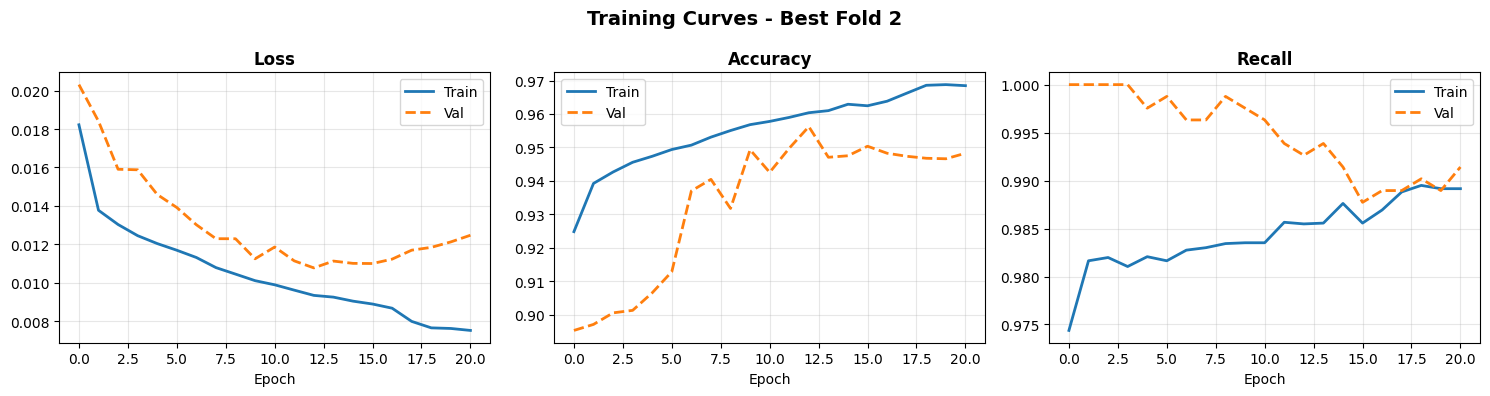


Final val accuracy : 0.9483
Final val recall   : 0.9914


In [19]:
best_fold = max(trained_models, key=lambda x: x["val_f1"])
history = best_fold["history"]

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle(f"Training Curves - Best Fold {best_fold['fold']}", fontsize=14, fontweight="bold")

for ax, metric, title in zip(
    axes,
    ["loss", "acc", "recall"],
    ["Loss", "Accuracy", "Recall"],
):
    ax.plot(history.history[metric], label="Train", linewidth=2)
    ax.plot(history.history[f"val_{metric}"], label="Val", linewidth=2, linestyle="--")
    ax.set_title(title, fontweight="bold")
    ax.set_xlabel("Epoch")
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(MODELS_DIR / "training_curves_best_fold.png", dpi=120, bbox_inches="tight")
plt.show()

final_val_acc = history.history["val_acc"][-1]
final_val_recall = history.history["val_recall"][-1]
print(f"\nFinal val accuracy : {final_val_acc:.4f}")
print(f"Final val recall   : {final_val_recall:.4f}")


TEST SET EVALUATION
              precision    recall  f1-score   support

      Normal     0.9541    0.9980    0.9755      5476
    Accident     0.4762    0.0366    0.0680       273

    accuracy                         0.9523      5749
   macro avg     0.7151    0.5173    0.5218      5749
weighted avg     0.9314    0.9523    0.9324      5749

Confusion Matrix:
  True Negatives  (TN): 5,465  — normal correctly ignored
  False Positives (FP): 11  — false alarms
  False Negatives (FN): 263  — ⚠️  missed accidents!
  True Positives  (TP): 10  — accidents correctly caught

False alarm rate (FPR): 0.0020
Miss rate        (FNR): 0.9634  ← critical for safety

ROC-AUC : 0.7198
PR-AUC  : 0.2370  ← primary metric (imbalanced classes)


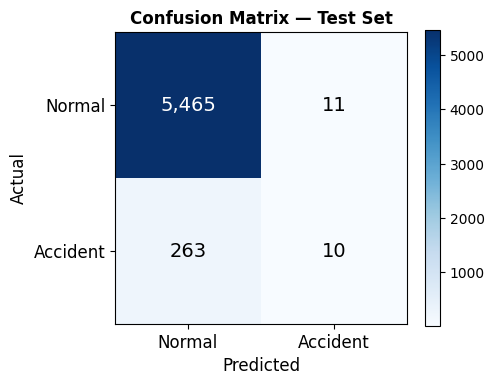

In [20]:
y_prob = model.predict(X_test, verbose=0).squeeze()
y_pred = (y_prob >= 0.5).astype(int)

print("=" * 55)
print("TEST SET EVALUATION")
print("=" * 55)
print(classification_report(y_test, y_pred, target_names=["Normal", "Accident"], digits=4))

cm = confusion_matrix(y_test, y_pred)
tn, fp, fn, tp = cm.ravel()
print(f"Confusion Matrix:")
print(f"  True Negatives  (TN): {tn:,}  — normal correctly ignored")
print(f"  False Positives (FP): {fp:,}  — false alarms")
print(f"  False Negatives (FN): {fn:,}  — ⚠️  missed accidents!")
print(f"  True Positives  (TP): {tp:,}  — accidents correctly caught")

fpr = fp / (fp + tn) if (fp + tn) > 0 else 0
fnr = fn / (fn + tp) if (fn + tp) > 0 else 0
print(f"\nFalse alarm rate (FPR): {fpr:.4f}")
print(f"Miss rate        (FNR): {fnr:.4f}  ← critical for safety")

roc    = roc_auc_score(y_test, y_prob)
prec_c, rec_c, _ = precision_recall_curve(y_test, y_prob)
pr_auc = auc(rec_c, prec_c)
print(f"\nROC-AUC : {roc:.4f}")
print(f"PR-AUC  : {pr_auc:.4f}  ← primary metric (imbalanced classes)")

# Confusion matrix heatmap
fig, ax = plt.subplots(figsize=(5, 4))
im = ax.imshow(cm, cmap='Blues')
ax.set_xticks([0, 1]); ax.set_yticks([0, 1])
ax.set_xticklabels(["Normal", "Accident"], fontsize=12)
ax.set_yticklabels(["Normal", "Accident"], fontsize=12)
ax.set_xlabel("Predicted", fontsize=12)
ax.set_ylabel("Actual", fontsize=12)
ax.set_title("Confusion Matrix — Test Set", fontweight='bold')
for i in range(2):
    for j in range(2):
        ax.text(j, i, f"{cm[i,j]:,}", ha='center', va='center', fontsize=14,
                color='white' if cm[i, j] > cm.max() / 2 else 'black')
plt.colorbar(im)
plt.tight_layout()
plt.savefig(MODELS_DIR / "confusion_matrix.png", dpi=120, bbox_inches='tight')
plt.show()


In [21]:
print(f"{'Threshold':>10} {'Recall':>8} {'Precision':>10} {'F1':>8} {'False Alarms':>14} {'Missed Accidents':>18}")
print("-" * 78)

threshold_rows = []
for thresh in np.arange(0.10, 0.91, 0.05):
    yp = (y_prob >= thresh).astype(int)
    tp_ = ((yp == 1) & (y_test == 1)).sum()
    fp_ = ((yp == 1) & (y_test == 0)).sum()
    fn_ = ((yp == 0) & (y_test == 1)).sum()
    recall_ = tp_ / (tp_ + fn_) if (tp_ + fn_) > 0 else 0
    precision_ = tp_ / (tp_ + fp_) if (tp_ + fp_) > 0 else 0
    f1_ = 2 * recall_ * precision_ / (recall_ + precision_) if (recall_ + precision_) > 0 else 0
    threshold_rows.append((thresh, recall_, precision_, f1_, fp_, fn_))

# Safety-oriented recommendation: require high recall first, then choose best precision.
candidates = [r for r in threshold_rows if r[1] >= 0.95]
recommended = max(candidates, key=lambda r: (r[2], r[3])) if candidates else max(threshold_rows, key=lambda r: r[3])

for thresh, recall_, precision_, f1_, fp_, fn_ in threshold_rows:
    marker = " <- recommended" if abs(thresh - recommended[0]) < 1e-9 else ""
    print(f"{thresh:>10.2f} {recall_:>8.3f} {precision_:>10.3f} {f1_:>8.3f} {fp_:>14,} {fn_:>18,}{marker}")

print(f"\nRecommended threshold: {recommended[0]:.2f}")
print("For the ESP32 app, start with this threshold, then validate with real riding tests.")


 Threshold   Recall  Precision       F1   False Alarms   Missed Accidents
------------------------------------------------------------------------------
      0.10    0.099      0.450    0.162             33                246 <- recommended
      0.15    0.092      0.481    0.154             27                248
      0.20    0.066      0.409    0.114             26                255
      0.25    0.059      0.410    0.103             23                257
      0.30    0.051      0.412    0.091             20                259
      0.35    0.048      0.419    0.086             18                260
      0.40    0.048      0.500    0.087             13                260
      0.45    0.044      0.500    0.081             12                261
      0.50    0.037      0.476    0.068             11                263
      0.55    0.029      0.500    0.055              8                265
      0.60    0.026      0.467    0.049              8                266
      0.65    0.01